In [1]:
import sys, os
sys.path.append("/Users/chris/Documents/higs-vision")

from src.data import load_config, load_processed
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

config = load_config("/Users/chris/Documents/higs-vision/config.yaml")
X_train, y_train, X_val, y_val, X_test, y_test, scaler = load_processed(config)

Loaded processed data from /Users/chris/Documents/higs-vision/data/processed/
  Train: (700000, 28), Val: (150000, 28), Test: (150000, 28)


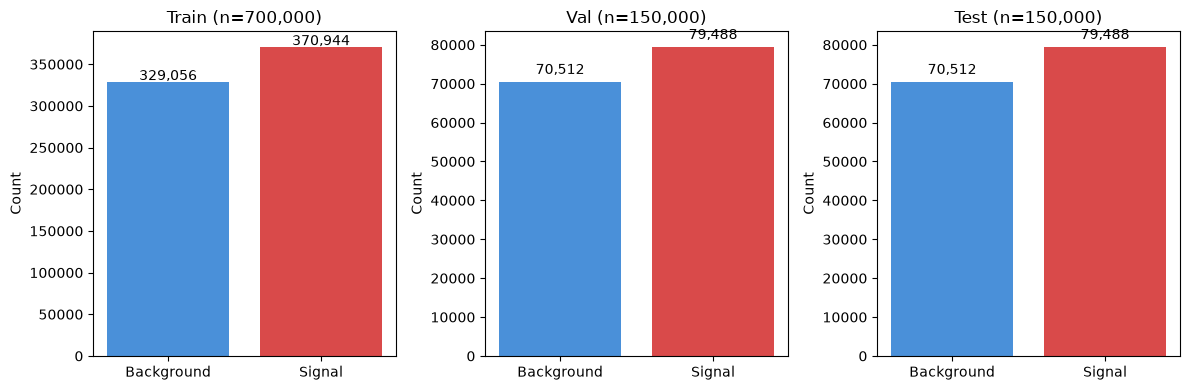

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (name, y) in zip(axes, [("Train", y_train), ("Val", y_val), ("Test", y_test)]):
    counts = [int((y == 0).sum()), int((y == 1).sum())]
    ax.bar(["Background", "Signal"], counts, color=["#4a90d9", "#d94a4a"])
    ax.set_title(f"{name} (n={len(y):,})")
    ax.set_ylabel("Count")
    for i, c in enumerate(counts):
        ax.text(i, c + 2000, f"{c:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("/Users/chris/Documents/higs-vision/figures/class_distribution.png", dpi=150)
plt.show()

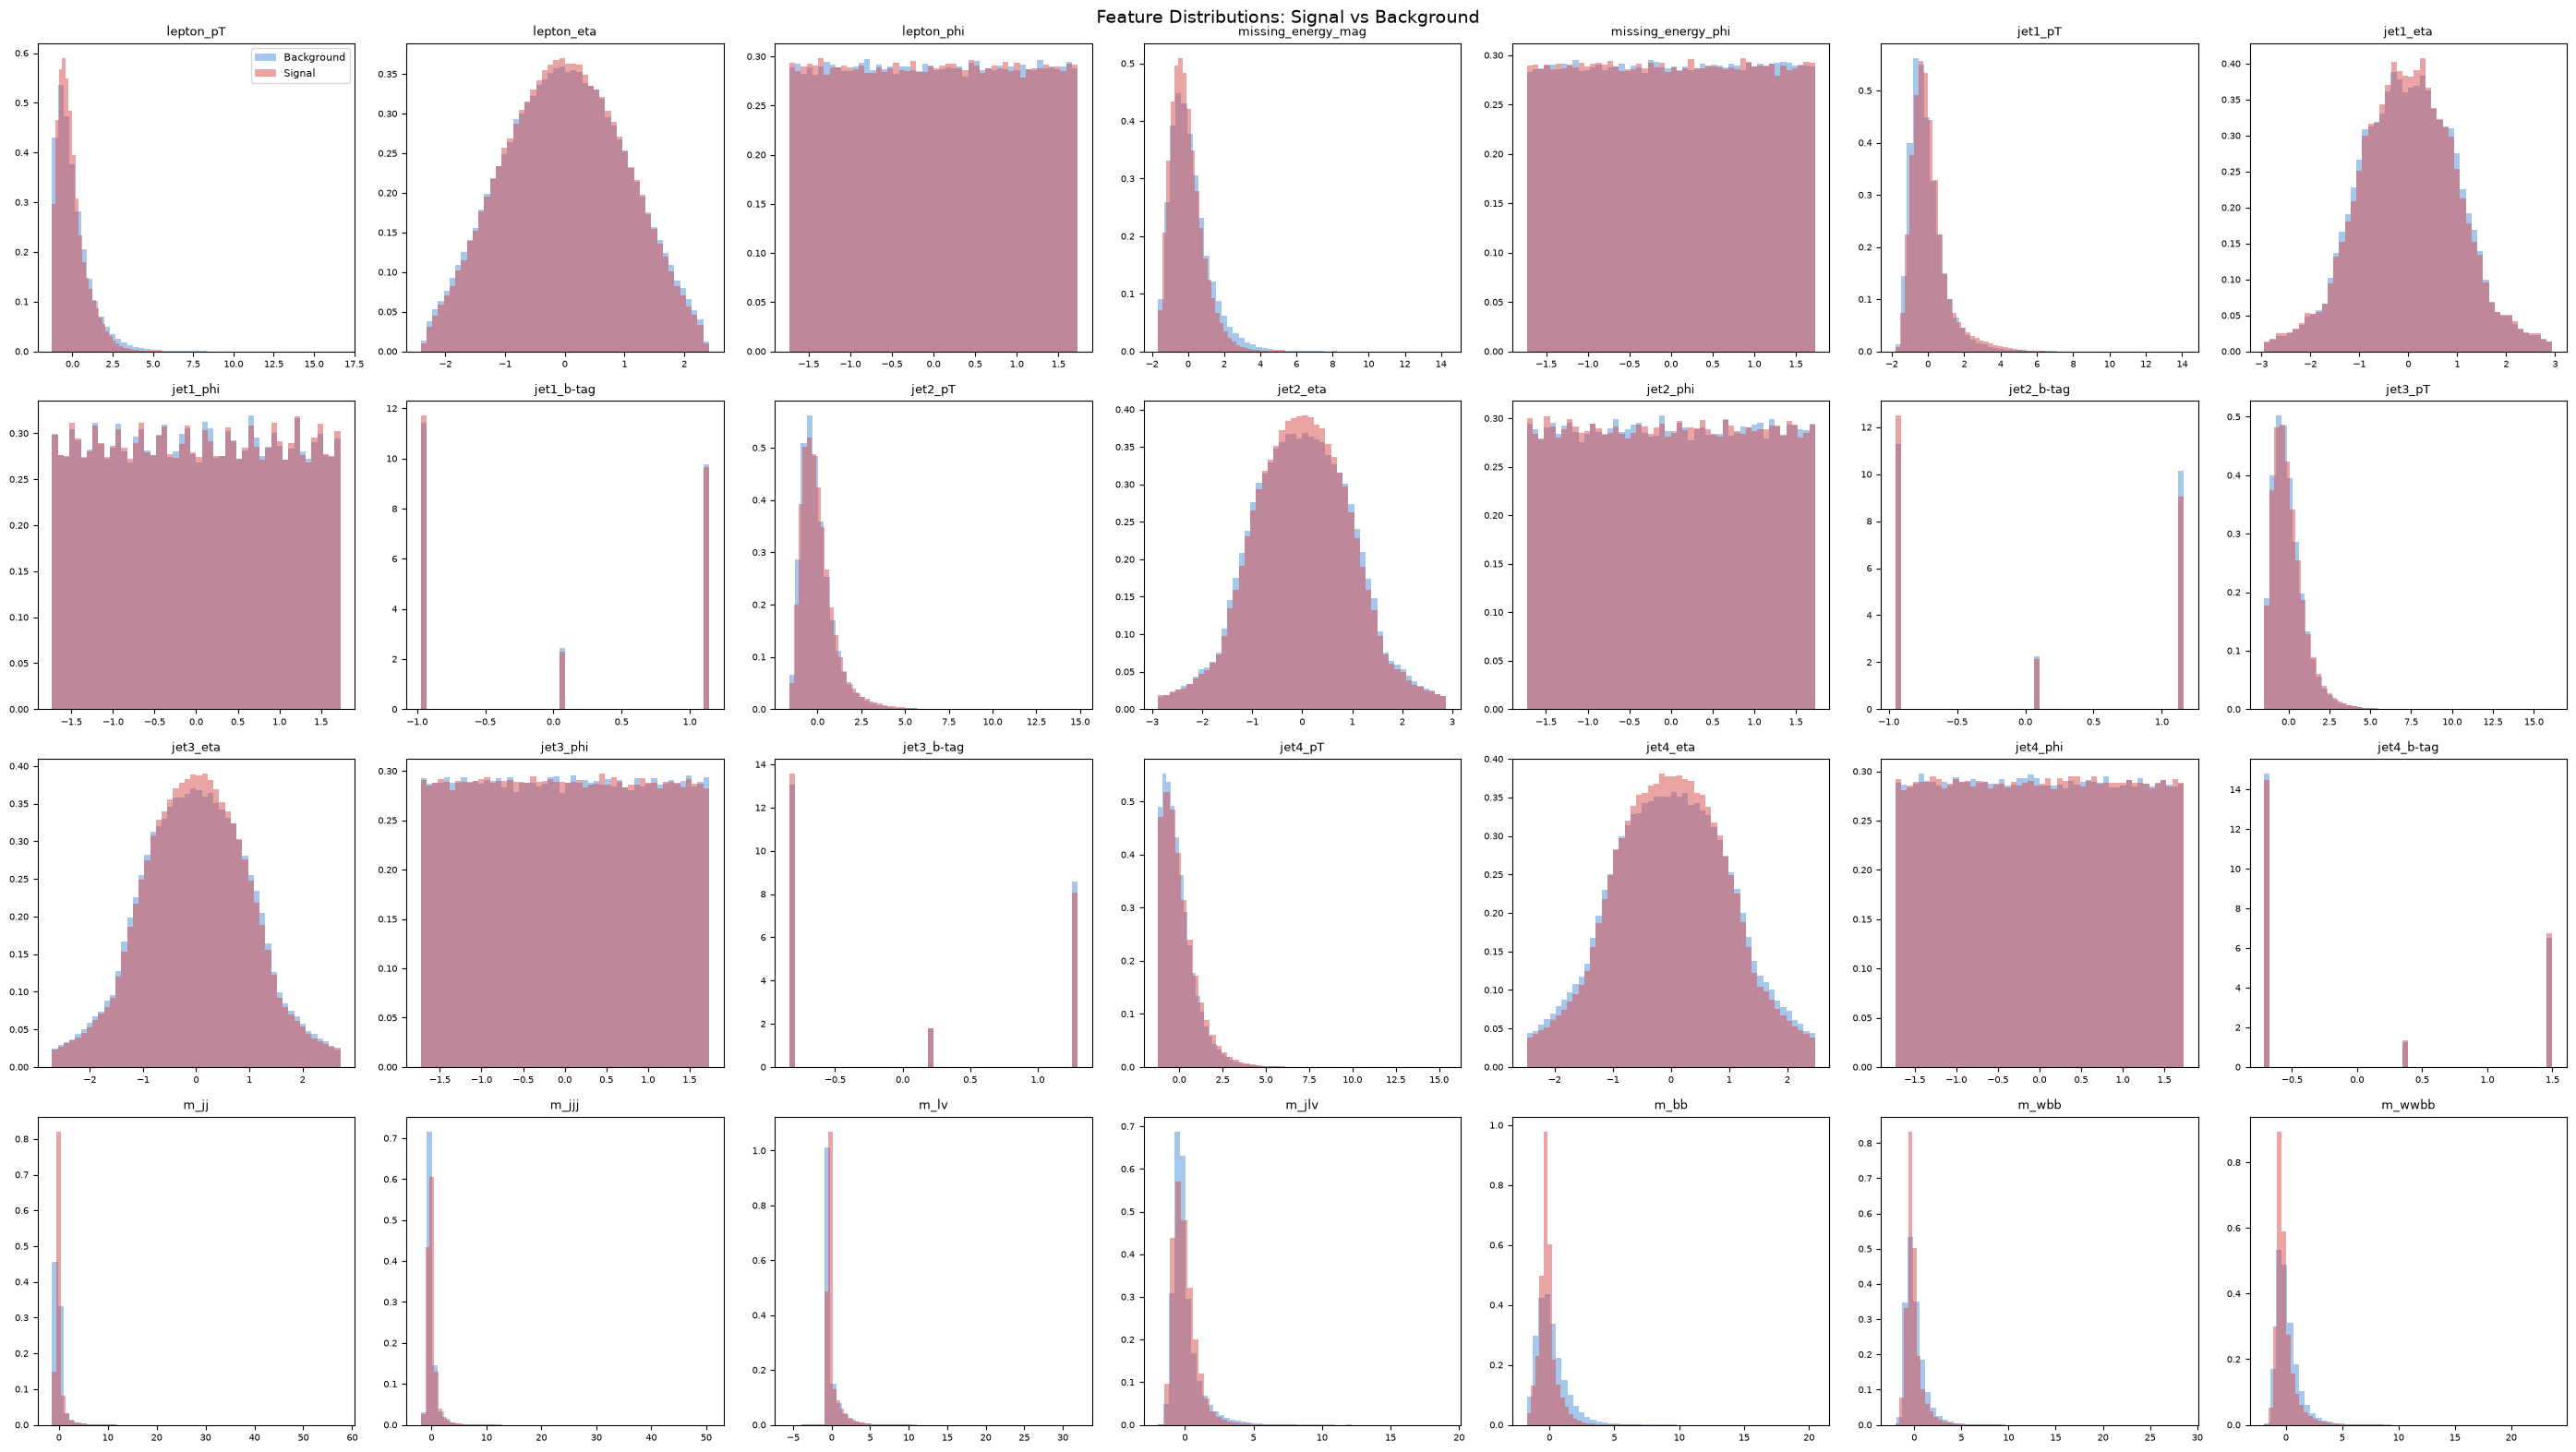

In [3]:
feature_names = [
    "lepton_pT", "lepton_eta", "lepton_phi",
    "missing_energy_mag", "missing_energy_phi",
    "jet1_pT", "jet1_eta", "jet1_phi", "jet1_b-tag",
    "jet2_pT", "jet2_eta", "jet2_phi", "jet2_b-tag",
    "jet3_pT", "jet3_eta", "jet3_phi", "jet3_b-tag",
    "jet4_pT", "jet4_eta", "jet4_phi", "jet4_b-tag",
    "m_jj", "m_jjj", "m_lv", "m_jlv", "m_bb", "m_wbb", "m_wwbb"
]

fig, axes = plt.subplots(4, 7, figsize=(28, 16))
axes = axes.flatten()

for i in range(28):
    ax = axes[i]
    ax.hist(X_train[y_train == 0, i], bins=50, alpha=0.5, label="Background", density=True, color="#4a90d9")
    ax.hist(X_train[y_train == 1, i], bins=50, alpha=0.5, label="Signal", density=True, color="#d94a4a")
    ax.set_title(feature_names[i], fontsize=9)
    ax.tick_params(labelsize=7)

axes[0].legend(fontsize=8)
plt.suptitle("Feature Distributions: Signal vs Background", fontsize=14)
plt.tight_layout()
plt.savefig("/Users/chris/Documents/higs-vision/figures/feature_distributions.png", dpi=150)
plt.show()

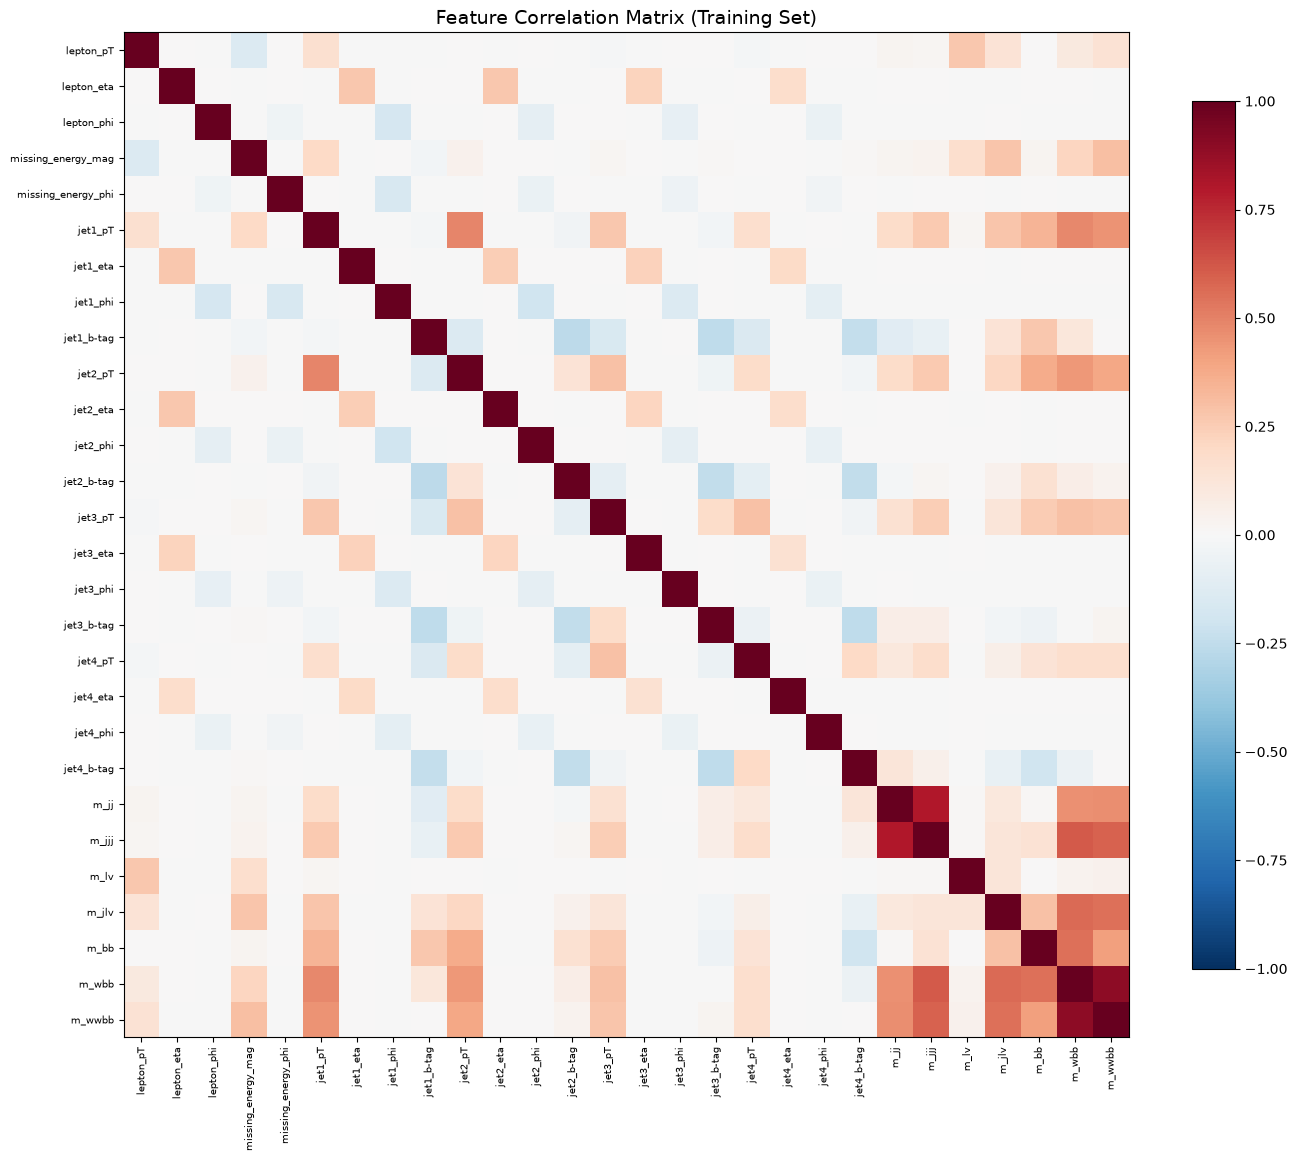

In [4]:
corr = np.corrcoef(X_train.T)

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(28))
ax.set_yticks(range(28))
ax.set_xticklabels(feature_names, rotation=90, fontsize=7)
ax.set_yticklabels(feature_names, fontsize=7)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Feature Correlation Matrix (Training Set)", fontsize=14)
plt.tight_layout()
plt.savefig("/Users/chris/Documents/higs-vision/figures/correlation_matrix.png", dpi=150)
plt.show()

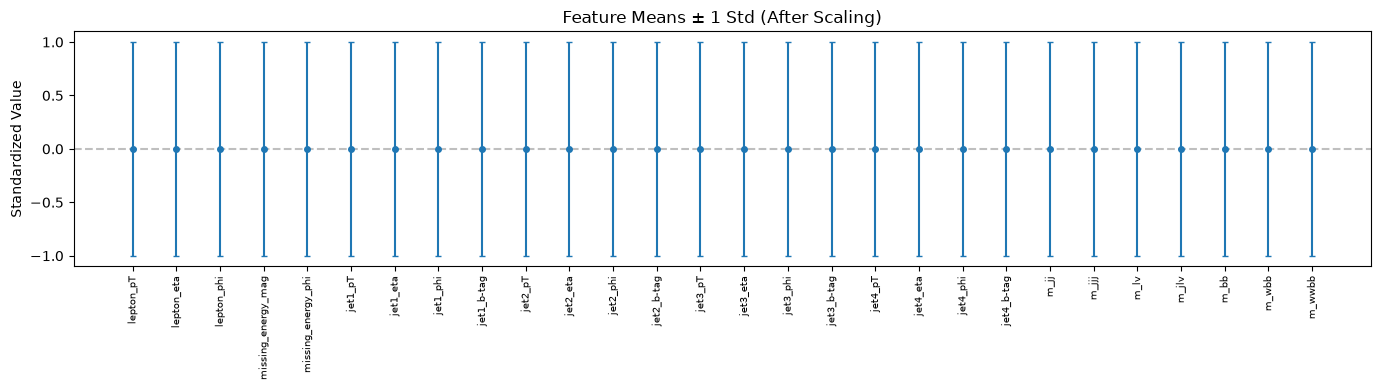

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
means = X_train.mean(axis=0)
stds = X_train.std(axis=0)
ax.errorbar(range(28), means, yerr=stds, fmt="o", markersize=4, capsize=2)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xticks(range(28))
ax.set_xticklabels(feature_names, rotation=90, fontsize=7)
ax.set_ylabel("Standardized Value")
ax.set_title("Feature Means ± 1 Std (After Scaling)")
plt.tight_layout()
plt.savefig("/Users/chris/Documents/higs-vision/figures/feature_scaling.png", dpi=150)
plt.show()

In [7]:
import numpy as np
corr = np.corrcoef(X_train.T)

# Find pairs above threshold
for i in range(28):
    for j in range(i+1, 28):
        if abs(corr[i, j]) > 0.5:
            print(f"{feature_names[i]:20s} {feature_names[j]:20s} {corr[i,j]:.3f}")

m_jj                 m_jjj                0.798
m_jjj                m_wbb                0.615
m_jjj                m_wwbb               0.589
m_jlv                m_wbb                0.568
m_jlv                m_wwbb               0.549
m_bb                 m_wbb                0.555
m_wbb                m_wwbb               0.896


In [ ]:
for i in range(28):
    n_unique = len(np.unique(X_train[:, i]))
    if n_unique < 20:
        print(f"{feature_names[i]:20s} {n_unique} unique values")




jet1_b-tag           3 unique values
jet2_b-tag           3 unique values
jet3_b-tag           3 unique values
jet4_b-tag           3 unique values


In [10]:
for i in range(28):
    p99 = np.percentile(X_train[:, i], 99)
    p01 = np.percentile(X_train[:, i], 1)
    if p99 > 5 or p01 < -5:
        print(f"{feature_names[i]:20s} range after scaling: [{p01:.1f}, {p99:.1f}]")